In [10]:
!pip install transformers
!pip install torch
!pip install pillow
!pip install matplotlib

Import Libraries

In [11]:
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
from PIL import Image
import requests
import matplotlib.pyplot as plt

Load the AI Model


In [12]:
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Load an Image


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

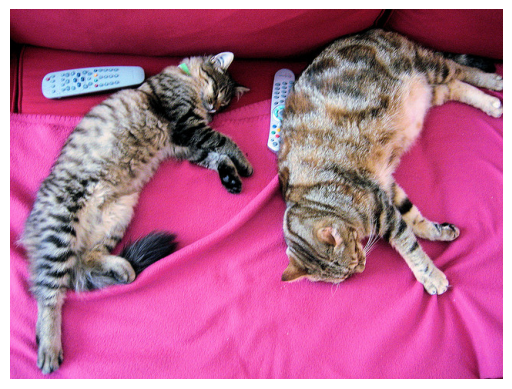

In [13]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

plt.imshow(image)
plt.axis("off")

Converting Image Into Model Input

In [14]:
inputs = processor(images=image, return_tensors="pt")

Run Object Detection

In [15]:
outputs = model(**inputs)

Process Detection Results

In [16]:
target_sizes = torch.tensor([image.size[::-1]])

results = processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.9
)[0]

Printing Detected Objects

In [17]:
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence {round(score.item(),3)}"
    )

Detected remote with confidence 0.998
Detected remote with confidence 0.996
Detected couch with confidence 0.995
Detected cat with confidence 0.999
Detected cat with confidence 0.999


Draw Bounding Boxes

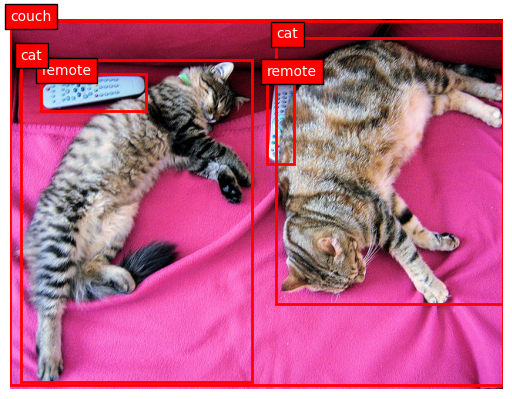

In [19]:
plt.imshow(image)
ax = plt.gca()

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    # Detach the tensor from the computation graph and convert to numpy array
    x1, y1, x2, y2 = box.detach().cpu().numpy()

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        color="red",
        linewidth=2,
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        model.config.id2label[label.item()],
        color="white",
        bbox=dict(facecolor="red"),
    )

plt.axis("off")
plt.show()